<a href="https://colab.research.google.com/github/franciscoqueirozzz/Checkpoint-3---Dynamic-Programing/blob/main/CP03_Dynamic_Programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#FIAP — Dynamic Programming | Checkpoint 3

---

## [1] Identificação do Grupo

| Nome Completo | RM |
|---|---|
| Francisco Nogueira de Queiroz | 566309 |
| Sara Marangon de Macedo| 563807 |
| Bruna Sadi Duarte | 561870 |
| Dennis Nieto Generoso | 563671 |
| Rhariel Marcelo Permanhani | 566310 |

**Disciplina:** Dynamic Programming

**Professor:** Andre Marques

**Turma:** 2ESA

## [2] Introdução

### Contexto do Desafio

Hoje em dia, sistemas de transporte em grandes cidades precisam ser cada vez mais eficientes. Pensando nisso, este projeto trabalha com três redes de metrô de cidades diferentes: **Beijing (China)**, **San Francisco (EUA)** e **São Paulo (Brasil)**.

A ideia é simular um sistema de rotas que consiga encontrar caminhos entre estações levando em conta não só a distância, mas também o horário do dia, já que o fluxo de pessoas muda bastante dependendo do período.

---

### Problema

As redes de metrô foram representadas como **grafos ponderados**, onde:

* Cada **estação** é um nó
* Cada **ligação entre estações** é uma aresta
* Cada aresta tem um **peso**, que representa o tempo de deslocamento

Além disso, esse tempo pode variar dependendo do horário, simulando situações como horários de pico e horários mais tranquilos.

---

### Objetivos

O projeto tem como principais objetivos:

1. Encontrar o **caminho mais curto** entre duas estações, usando recursão com memoização (`lru_cache`)
2. Encontrar o **caminho mais longo possível**, sem repetir estações, usando backtracking
3. Aplicar um **fator de horário**, que altera o custo das viagens
4. Comparar o desempenho do algoritmo com e sem memoização
5. Exibir os resultados em **mapas interativos**, para facilitar a visualização

---

### Por que usar grafo não-direcionado?

Foi escolhido usar grafos **não-direcionados** porque, na prática, o metrô funciona nos dois sentidos. Ou seja, dá pra ir e voltar entre estações usando o mesmo caminho.

Isso simplifica o modelo e continua representando bem a realidade.

---

### Importância do Projeto

Esse projeto ajuda a entender, na prática, como algoritmos podem ser usados para resolver problemas reais, como encontrar rotas em sistemas de transporte.

Além disso, mostra como pequenas mudanças, como considerar o horário, podem impactar bastante no resultado final.


## Instalação de Dependências

In [314]:
# Instalação das bibliotecas necessárias
!pip install folium matplotlib -q
print("Bibliotecas instaladas com sucesso!")


Bibliotecas instaladas com sucesso!


## Imports Globais

In [315]:
import time
import tracemalloc
import functools
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
import math

print("Imports realizados com sucesso!")


Imports realizados com sucesso!


## [3] Modelagem do Grafo

### Teoria

Neste projeto, a rede de metrô foi representada como um **grafo ponderado**, que pode ser descrito como G = (V, E, w), onde:

* **V** representa o conjunto de vértices (as estações)
* **E** representa o conjunto de arestas (as conexões entre as estações)
* **w** é a função que define o peso de cada aresta, ou seja, o tempo de deslocamento em minutos

Essa estrutura permite modelar o sistema de transporte de forma simples e ao mesmo tempo eficiente.

---

### Estrutura de Dados

Para representar o grafo no código, foi utilizada uma **lista de adjacência**, implementada com um dicionário em Python:

```python
grafo = {
    "Estacao_A": [("Estacao_B", peso), ("Estacao_C", peso)],
    ...
}
```

Nesse formato, cada estação aponta para suas vizinhas junto com o tempo necessário para chegar até elas.

Como o grafo é **não-direcionado**, cada conexão aparece nos dois sentidos. Ou seja, se existe uma ligação entre A e B, então:

* A lista de A contém B
* A lista de B contém A

---

### Complexidade Espacial

A escolha da lista de adjacência foi feita por ser mais eficiente para esse tipo de problema.

* O espaço utilizado é **O(V + E)**
* Em comparação, uma matriz de adjacência teria custo **O(V²)**

Como redes de metrô são relativamente esparsas (cada estação conecta com poucas outras), a lista de adjacência se torna uma opção mais adequada.

---

### Observação

Além disso, essa estrutura facilita a implementação dos algoritmos de busca, já que permite acessar rapidamente todas as conexões de uma estação.


###Grafo de Beijing

Linhas utilizadas: **1, 2, 4 e 10**  
Origem: **Sihui East** | Destino: **Xizhimen**

As estações e pesos refletem tempos reais entre estações adjacentes (estimados entre 2–8 min).


In [316]:
# Formato: { "Estação": [("Vizinha", peso_minutos), ...] }

grafo_beijing = {
    # Linha 1 (Leste-Oeste)
    "Sihui East":       [("Sihui", 3)],
    "Sihui":            [("Sihui East", 3), ("Guomao", 4)],
    "Guomao":           [("Sihui", 4), ("Yong'anli", 3), ("Jianguomen", 4)],
    "Yong'anli":        [("Guomao", 3), ("Jianguomen", 3)],
    "Jianguomen":       [("Yong'anli", 3), ("Guomao", 4), ("Beijing Station", 4),
                         ("Chaoyangmen", 3)],  # Conexão Linha 2
    "Beijing Station":  [("Jianguomen", 4), ("Wangfujing", 4)],
    "Wangfujing":       [("Beijing Station", 4), ("Tian'anmen East", 3)],
    "Tian'anmen East":  [("Wangfujing", 3), ("Tian'anmen West", 3)],
    "Tian'anmen West":  [("Tian'anmen East", 3), ("Xidan", 3), ("Qianmen", 3)],  # Linha 2
    "Xidan":            [("Tian'anmen West", 3), ("Fuxingmen", 4)],
    "Fuxingmen":        [("Xidan", 4), ("Muxidi", 4), ("Fuchengmen", 3)],  # Linha 2

    # Linha 2 (Circular)
    "Chaoyangmen":      [("Jianguomen", 3), ("Dongdaqiao", 3)],
    "Dongdaqiao":       [("Chaoyangmen", 3), ("Chaoyang Gate", 3)],
    "Qianmen":          [("Tian'anmen West", 3), ("Hepingmen", 3)],
    "Hepingmen":        [("Qianmen", 3), ("Xuanwumen", 3)],
    "Xuanwumen":        [("Hepingmen", 3), ("Changchunjie", 3)],
    "Changchunjie":     [("Xuanwumen", 3), ("Fuchengmen", 4)],
    "Fuchengmen":       [("Changchunjie", 4), ("Fuxingmen", 3), ("Chegongzhuang", 4)],
    "Chegongzhuang":    [("Fuchengmen", 4), ("Xizhimen", 5)],  # Chegada!

    # Linha 4 (Norte-Sul — conexões)
    "Muxidi":           [("Fuxingmen", 4), ("Linglong Road", 5)],
    "Linglong Road":    [("Muxidi", 5), ("Haidianhuangzhuang", 6)],
    "Haidianhuangzhuang": [("Linglong Road", 6), ("Zhongguancun", 4)],
    "Zhongguancun":     [("Haidianhuangzhuang", 4), ("Haidian Wuluju", 3)],
    "Haidian Wuluju":   [("Zhongguancun", 3), ("Renmin University", 4)],
    "Renmin University":[("Haidian Wuluju", 4)],

    # Linha 10 (Anel Exterior — conexões)
    "Chaoyang Gate":    [("Dongdaqiao", 3), ("Tuanjiehu", 4)],
    "Tuanjiehu":        [("Chaoyang Gate", 4), ("Hujialou", 3)],
    "Hujialou":         [("Tuanjiehu", 3), ("Liangmaqiao", 4)],
    "Liangmaqiao":      [("Hujialou", 4), ("Sanyuanqiao", 4)],
    "Sanyuanqiao":      [("Liangmaqiao", 4), ("Anzhenmen", 5)],
    "Anzhenmen":        [("Sanyuanqiao", 5), ("Xizhimen", 6)],  # Outro caminho para destino

    # Destino
    "Xizhimen":         [("Chegongzhuang", 5), ("Anzhenmen", 6)],
}

# Verificação de estações
total_estacoes = len(grafo_beijing)
print(f"Grafo Beijing criado com {total_estacoes} estações")
print("   Origem: Sihui East | Destino: Xizhimen")
print("   Linhas: 1, 2, 4 e 10")


Grafo Beijing criado com 32 estações
   Origem: Sihui East | Destino: Xizhimen
   Linhas: 1, 2, 4 e 10


In [317]:
# Coordenadas geográficas das estações de Beijing
coords_beijing = {
    "Sihui East":           (39.9019, 116.5007),
    "Sihui":                (39.9024, 116.4877),
    "Guomao":               (39.9086, 116.4612),
    "Yong'anli":            (39.9092, 116.4490),
    "Jianguomen":           (39.9094, 116.4342),
    "Beijing Station":      (39.9026, 116.4280),
    "Wangfujing":           (39.9143, 116.4085),
    "Tian'anmen East":      (39.9074, 116.3970),
    "Tian'anmen West":      (39.9068, 116.3907),
    "Xidan":                (39.9121, 116.3669),
    "Fuxingmen":            (39.9147, 116.3540),
    "Muxidi":               (39.9163, 116.3372),
    "Chaoyangmen":          (39.9268, 116.4340),
    "Dongdaqiao":           (39.9251, 116.4640),
    "Qianmen":              (39.8994, 116.3941),
    "Hepingmen":            (39.9019, 116.3810),
    "Xuanwumen":            (39.8987, 116.3714),
    "Changchunjie":         (39.8984, 116.3602),
    "Fuchengmen":           (39.9240, 116.3481),
    "Chegongzhuang":        (39.9367, 116.3432),
    "Xizhimen":             (39.9430, 116.3531),
    "Linglong Road":        (39.9273, 116.3272),
    "Haidianhuangzhuang":   (39.9768, 116.3130),
    "Zhongguancun":         (39.9833, 116.3109),
    "Haidian Wuluju":       (39.9938, 116.3087),
    "Renmin University":    (39.9629, 116.3176),
    "Chaoyang Gate":        (39.9276, 116.4416),
    "Tuanjiehu":            (39.9397, 116.4607),
    "Hujialou":             (39.9406, 116.4717),
    "Liangmaqiao":          (39.9487, 116.4724),
    "Sanyuanqiao":          (39.9643, 116.4722),
    "Anzhenmen":            (39.9688, 116.3835),
}

print(f"Coordenadas Beijing: {len(coords_beijing)} estações mapeadas")


Coordenadas Beijing: 32 estações mapeadas


###Grafo de San Francisco — BART

Linhas utilizadas: **Blue Line, Yellow Line e Green Line**  
Origem: **Dublin/Pleasanton** | Destino: **Daly City**


In [318]:

# SAN FRANCISCO — Rede BART

grafo_sf = {
    # Linha Azul (Blue) — Dublin/Pleasanton até SF
    "Dublin/Pleasanton":    [("West Dublin/Pleasanton", 4)],
    "West Dublin/Pleasanton": [("Dublin/Pleasanton", 4), ("Castro Valley", 6)],
    "Castro Valley":        [("West Dublin/Pleasanton", 6), ("Bay Fair", 5)],
    "Bay Fair":             [("Castro Valley", 5), ("San Leandro", 4), ("Hayward", 5)],
    "San Leandro":          [("Bay Fair", 4), ("Fruitvale", 5)],
    "Fruitvale":            [("San Leandro", 5), ("Lake Merritt", 4)],
    "Lake Merritt":         [("Fruitvale", 4), ("Oakland City Center/12th St", 3)],
    "Oakland City Center/12th St": [("Lake Merritt", 3), ("19th Street Oakland", 3),
                                     ("West Oakland", 6)],
    "19th Street Oakland":  [("Oakland City Center/12th St", 3), ("MacArthur", 4)],
    "MacArthur":            [("19th Street Oakland", 4), ("Rockridge", 5),
                              ("Ashby", 5)],   # Bifurcação Amarela/Verde
    "Rockridge":            [("MacArthur", 5), ("Orinda", 7)],
    "Orinda":               [("Rockridge", 7), ("Lafayette", 5)],
    "Lafayette":            [("Orinda", 5), ("Walnut Creek", 6)],
    "Walnut Creek":         [("Lafayette", 6), ("Pleasant Hill", 5)],
    "Pleasant Hill":        [("Walnut Creek", 5), ("Concord", 5)],
    "Concord":              [("Pleasant Hill", 5), ("North Concord/Martinez", 5)],
    "North Concord/Martinez": [("Concord", 5)],

    # West Oakland → SF (túnel transbay)
    "West Oakland":         [("Oakland City Center/12th St", 6), ("Embarcadero", 7)],
    "Embarcadero":          [("West Oakland", 7), ("Montgomery St", 3)],
    "Montgomery St":        [("Embarcadero", 3), ("Powell St", 2)],
    "Powell St":            [("Montgomery St", 2), ("Civic Center/UN Plaza", 2)],
    "Civic Center/UN Plaza": [("Powell St", 2), ("16th Street Mission", 4)],
    "16th Street Mission":  [("Civic Center/UN Plaza", 4), ("24th Street Mission", 3)],
    "24th Street Mission":  [("16th Street Mission", 3), ("Glen Park", 4)],
    "Glen Park":            [("24th Street Mission", 4), ("Balboa Park", 4)],
    "Balboa Park":          [("Glen Park", 4), ("Daly City", 5), ("Colma", 6)],

    # Linha Verde (Green) — via Ashby
    "Ashby":                [("MacArthur", 5), ("Downtown Berkeley", 4)],
    "Downtown Berkeley":    [("Ashby", 4), ("North Berkeley", 3)],
    "North Berkeley":       [("Downtown Berkeley", 3), ("El Cerrito Plaza", 4)],
    "El Cerrito Plaza":     [("North Berkeley", 4), ("El Cerrito del Norte", 3)],
    "El Cerrito del Norte": [("El Cerrito Plaza", 3), ("Richmond", 5)],
    "Richmond":             [("El Cerrito del Norte", 5)],

    # Linha Amarela — via Hayward
    "Hayward":              [("Bay Fair", 5), ("South Hayward", 4)],
    "South Hayward":        [("Hayward", 4), ("Union City", 5)],
    "Union City":           [("South Hayward", 5), ("Fremont", 5)],
    "Fremont":              [("Union City", 5)],

    # Destino
    "Daly City":            [("Balboa Park", 5), ("Colma", 4)],
    "Colma":                [("Daly City", 4), ("Balboa Park", 6)],
}

total_estacoes_sf = len(grafo_sf)
print(f"Grafo San Francisco (BART) criado com {total_estacoes_sf} estações")
print("   Origem: Dublin/Pleasanton | Destino: Daly City")
print("   Linhas: Blue, Yellow e Green")


Grafo San Francisco (BART) criado com 38 estações
   Origem: Dublin/Pleasanton | Destino: Daly City
   Linhas: Blue, Yellow e Green


In [319]:
# Coordenadas geográficas BART
coords_sf = {
    "Dublin/Pleasanton":        (37.7018, -121.9002),
    "West Dublin/Pleasanton":   (37.6993, -121.9278),
    "Castro Valley":            (37.6903, -122.0757),
    "Bay Fair":                 (37.6969, -122.1263),
    "San Leandro":              (37.7022, -122.1607),
    "Fruitvale":                (37.7749, -122.2240),
    "Lake Merritt":             (37.7977, -122.2650),
    "Oakland City Center/12th St": (37.8032, -122.2724),
    "19th Street Oakland":      (37.8086, -122.2686),
    "MacArthur":                (37.8285, -122.2675),
    "Rockridge":                (37.8442, -122.2519),
    "Orinda":                   (37.8784, -122.1836),
    "Lafayette":                (37.8930, -122.1240),
    "Walnut Creek":             (37.9055, -122.0677),
    "Pleasant Hill":            (37.9282, -122.0563),
    "Concord":                  (37.9735, -122.0296),
    "North Concord/Martinez":   (38.0031, -122.0242),
    "West Oakland":             (37.8047, -122.2946),
    "Embarcadero":              (37.7929, -122.3971),
    "Montgomery St":            (37.7893, -122.4017),
    "Powell St":                (37.7844, -122.4079),
    "Civic Center/UN Plaza":    (37.7796, -122.4148),
    "16th Street Mission":      (37.7650, -122.4197),
    "24th Street Mission":      (37.7524, -122.4182),
    "Glen Park":                (37.7330, -122.4339),
    "Balboa Park":              (37.7219, -122.4473),
    "Daly City":                (37.7062, -122.4690),
    "Colma":                    (37.6845, -122.4666),
    "Ashby":                    (37.8530, -122.2700),
    "Downtown Berkeley":        (37.8701, -122.2683),
    "North Berkeley":           (37.8745, -122.2832),
    "El Cerrito Plaza":         (37.9020, -122.2993),
    "El Cerrito del Norte":     (37.9253, -122.3170),
    "Richmond":                 (37.9369, -122.3534),
    "Hayward":                  (37.6704, -122.0885),
    "South Hayward":            (37.6343, -122.0572),
    "Union City":               (37.5913, -122.0172),
    "Fremont":                  (37.5573, -121.9760),
}

print(f"Coordenadas BART: {len(coords_sf)} estações mapeadas")


Coordenadas BART: 38 estações mapeadas


###Grafo de São Paulo — Metrô + CPTM

Linhas utilizadas: **Linha 1 (Azul), Linha 2 (Verde), Linha 3 (Vermelha), Linha 4 (Amarela) e Linha 5 (Lilás)**  
Origem: **Tucuruvi** (Linha 1) | Destino: **Capão Redondo** (Linha 5)  
Integração obrigatória via estações como: **Sé, Luz, Pinheiros, Consolação**


In [320]:
grafo_sp = {
    # LINHA 1 — AZUL

    "Tucuruvi": [("Parada Inglesa", 3)],
    "Parada Inglesa": [("Tucuruvi", 3), ("Jardim São Paulo", 3)],
    "Jardim São Paulo": [("Parada Inglesa", 3), ("Santana", 3)],
    "Santana": [("Jardim São Paulo", 3), ("Carandiru", 3)],
    "Carandiru": [("Santana", 3), ("Portuguesa-Tietê", 3)],
    "Portuguesa-Tietê": [("Carandiru", 3), ("Armênia", 3)],
    "Armênia": [("Portuguesa-Tietê", 3), ("Tiradentes", 3)],
    "Tiradentes": [("Armênia", 3), ("Luz", 3)],

    # LUZ: Integração L1 e L4
    "Luz": [("Tiradentes", 3), ("São Bento", 3), ("República", 4)],

    "São Bento": [("Luz", 3), ("Sé", 3)],

    # SÉ: Integração L1 e L3
    "Sé": [("São Bento", 3), ("Liberdade", 3), ("Anhangabaú", 3)],

    "Liberdade": [("Sé", 3), ("São Joaquim", 3)],
    "São Joaquim": [("Liberdade", 3), ("Vergueiro", 3)],
    "Vergueiro": [("São Joaquim", 3), ("Paraíso", 3)],

    # PARAÍSO: Integração L1 e L2
    "Paraíso": [("Vergueiro", 3), ("Ana Rosa", 3), ("Brigadeiro", 3)],

    # ANA ROSA: Integração L1 e L2
    "Ana Rosa": [("Paraíso", 3), ("Vila Mariana", 3), ("Chácara Klabin", 4)],

    "Vila Mariana": [("Ana Rosa", 3), ("Santa Cruz", 3)],

    # SANTA CRUZ: Integração L1 e L5
    "Santa Cruz": [
        ("Vila Mariana", 3),
        ("Praça da Árvore", 3),
        ("Hospital São Paulo", 3),
        ("Chácara Klabin", 4)
    ],

    "Praça da Árvore": [("Santa Cruz", 3), ("Saúde", 3)],
    "Saúde": [("Praça da Árvore", 3), ("São Judas", 3)],
    "São Judas": [("Saúde", 3), ("Jabaquara", 4)],
    "Jabaquara": [("São Judas", 4)],

    # LINHA 5 — LILÁS

    "Capão Redondo": [("Campo Limpo", 4)],
    "Campo Limpo": [("Capão Redondo", 4), ("Vila das Belezas", 3)],
    "Vila das Belezas": [("Campo Limpo", 3), ("Giovanni Gronchi", 3)],
    "Giovanni Gronchi": [("Vila das Belezas", 3), ("Santo Amaro", 5)],
    "Santo Amaro": [("Giovanni Gronchi", 5), ("Largo Treze", 3)],
    "Largo Treze": [("Santo Amaro", 3), ("Adolfo Pinheiro", 3)],
    "Adolfo Pinheiro": [("Largo Treze", 3), ("Alto da Boa Vista", 3)],
    "Alto da Boa Vista": [("Adolfo Pinheiro", 3), ("Borba Gato", 3)],
    "Borba Gato": [("Alto da Boa Vista", 3), ("Brooklin", 3)],
    "Brooklin": [("Borba Gato", 3), ("Campo Belo", 3)],
    "Campo Belo": [("Brooklin", 3), ("Eucaliptos", 3)],
    "Eucaliptos": [("Campo Belo", 3), ("Moema", 3)],
    "Moema": [("Eucaliptos", 3), ("AACD-Servidor", 3)],
    "AACD-Servidor": [("Moema", 3), ("Hospital São Paulo", 3)],
    "Hospital São Paulo": [("AACD-Servidor", 3), ("Santa Cruz", 3)],

    # LINHA 2 — VERDE

    "Chácara Klabin": [("Ana Rosa", 4), ("Santa Cruz", 4)],
    "Trianon-Masp": [("Consolação", 3), ("Brigadeiro", 3)],
    "Brigadeiro": [("Trianon-Masp", 3), ("Paraíso", 3)],

    # LINHAS 3 E 4 — VERMELHA E AMARELA (ORDEM CORRIGIDA)

    "Anhangabaú": [("Sé", 3), ("República", 3)],

    "República": [("Anhangabaú", 3), ("Santa Cecília", 3), ("Luz", 4), ("Consolação", 4)],

    "Santa Cecília": [("República", 3), ("Marechal Deodoro", 3)],
    "Marechal Deodoro": [("Santa Cecília", 3), ("Barra Funda", 4)],
    "Barra Funda": [("Marechal Deodoro", 4)],

    # CONSOLAÇÃO: Integração L4 e L2
    "Consolação": [("República", 4), ("Faria Lima", 4), ("Trianon-Masp", 3)],
    "Faria Lima": [("Consolação", 4), ("Pinheiros", 4)],
    "Pinheiros": [("Faria Lima", 4)]
}

In [321]:
coords_sp = {
    # LINHA 1 — AZUL

    "Tucuruvi": (-23.4736, -46.6094),
    "Parada Inglesa": (-23.4846, -46.6215),
    "Jardim São Paulo": (-23.4930, -46.6272),
    "Santana": (-23.5034, -46.6286),
    "Carandiru": (-23.5115, -46.6286),
    "Portuguesa-Tietê": (-23.5188, -46.6262),
    "Armênia": (-23.5264, -46.6254),
    "Tiradentes": (-23.5339, -46.6254),
    "Luz": (-23.5392, -46.6335),
    "São Bento": (-23.5408, -46.6337),
    "Sé": (-23.5499, -46.6336),
    "Liberdade": (-23.5593, -46.6336),
    "São Joaquim": (-23.5645, -46.6395),
    "Vergueiro": (-23.5685, -46.6398),
    "Paraíso": (-23.5769, -46.6399),
    "Ana Rosa": (-23.5905, -46.6394),
    "Vila Mariana": (-23.5980, -46.6388),
    "Santa Cruz": (-23.5861, -46.6327),
    "Praça da Árvore": (-23.6012, -46.6367),
    "Saúde": (-23.6105, -46.6360),
    "São Judas": (-23.6167, -46.6350),
    "Jabaquara": (-23.6261, -46.6259),

    # LINHA 5 — LILÁS

    "Capão Redondo": (-23.6668, -46.7747),
    "Campo Limpo": (-23.6571, -46.7577),
    "Vila das Belezas": (-23.6523, -46.7490),
    "Giovanni Gronchi": (-23.6349, -46.7491),
    "Santo Amaro": (-23.6511, -46.7106),
    "Largo Treze": (-23.6482, -46.7034),
    "Adolfo Pinheiro": (-23.6380, -46.6991),
    "Alto da Boa Vista": (-23.6327, -46.6887),
    "Borba Gato": (-23.6264, -46.6878),
    "Brooklin": (-23.6152, -46.6868),
    "Campo Belo": (-23.6095, -46.6820),
    "Eucaliptos": (-23.6031, -46.6476),
    "Moema": (-23.5993, -46.6509),
    "AACD-Servidor": (-23.5982, -46.6389),
    "Hospital São Paulo": (-23.5925, -46.6363),

    # LINHA 2 — VERDE

    "Chácara Klabin": (-23.5984, -46.6314),
    "Trianon-Masp": (-23.5625, -46.6553),
    "Brigadeiro": (-23.5684, -46.6474),

    # LINHAS 3 E 4 — VERMELHA E AMARELA

    "República": (-23.5432, -46.6424),
    "Anhangabaú": (-23.5476, -46.6393),
    "Santa Cecília": (-23.5385, -46.6488),
    "Marechal Deodoro": (-23.5332, -46.6554),
    "Barra Funda": (-23.5252, -46.6661),
    "Consolação": (-23.5579, -46.6590),
    "Faria Lima": (-23.5763, -46.6884),
    "Pinheiros": (-23.5669, -46.7012)
}

## [4] Algoritmos

### Caminho Mais Curto — Recursão + Memoização

A ideia do algoritmo é explorar recursivamente todos os caminhos possíveis entre a estação de origem e a de destino, evitando ciclos com o uso de um conjunto de visitados.

Para melhorar o desempenho, foi utilizada memoização com `lru_cache`, que armazena resultados de chamadas já feitas. Assim, quando o algoritmo encontra o mesmo estado novamente, ele reutiliza o resultado em vez de recalcular tudo.

Isso faz bastante diferença em grafos com muitas rotas possíveis.

#### Complexidade

| Aspecto | Sem Memoização | Com Memoização                    |
| ------- | -------------- | --------------------------------- |
| Tempo   | Exponencial    | Exponencial (reduzido na prática) |
| Espaço  | O(V) (pilha)   | Maior devido ao cache             |

Na prática, a memoização reduz bastante o tempo de execução, principalmente porque evita repetir cálculos de subcaminhos que já foram analisados.

---

### Caminho Mais Longo Simples — Backtracking

Nesse caso, o objetivo é encontrar o caminho com maior custo possível entre duas estações, sem repetir nenhuma delas.

Para isso, foi usado backtracking, que basicamente testa todos os caminhos possíveis, voltando atrás sempre que necessário para explorar novas possibilidades.

Diferente do caminho mais curto, aqui não é viável usar memoização de forma eficiente.

#### Por que não usar memoização?

Porque o resultado depende não só da estação atual, mas também de quais estações já foram visitadas. Isso faz com que o número de estados possíveis cresça muito, tornando o uso de cache pouco eficiente.

#### Complexidade

* **Tempo:** Exponencial (pode crescer muito rápido dependendo do grafo)
* **Espaço:** O(V), devido à pilha de recursão

---

### Observação

Apesar do alto custo teórico, os algoritmos funcionam bem para o tamanho das redes utilizadas no projeto, permitindo comparar diferentes estratégias e entender melhor o impacto da otimização com memoização.


In [322]:
import functools
# FATOR DE HORÁRIO

def fator_horario(hora: int) -> float:
    """
    Define o multiplicador de custo conforme o horário do dia.
    """

    # validação básica
    if not isinstance(hora, int) or hora < 0 or hora > 23:
        raise ValueError("A hora deve ser um inteiro entre 0 e 23.")

    # faixas de horário
    if 5 <= hora < 7:
        return 0.6   # bônus (metrô vazio)
    elif 7 <= hora < 9:
        return 1.5   # pico da manhã
    elif 9 <= hora < 17:
        return 1.0   # normal
    elif 17 <= hora < 20:
        return 2.0   # pico da tarde
    else:
        return 1.0   # restante do dia


# TESTE

horarios_teste = [5, 7, 9, 17, 20, 23, 0]

for h in horarios_teste:
    print(f"Hora {h:02d}h → fator {fator_horario(h)}")

Hora 05h → fator 0.6
Hora 07h → fator 1.5
Hora 09h → fator 1.0
Hora 17h → fator 2.0
Hora 20h → fator 1.0
Hora 23h → fator 1.0
Hora 00h → fator 1.0


In [323]:
# CAMINHO MAIS CURTO (com memoização)

def caminho_mais_curto(grafo, origem, destino, hora):
    fator = fator_horario(hora)

    @functools.lru_cache(maxsize=None)
    def dfs(atual, visitados):
        if atual == destino:
            return 0.0, [destino]

        melhor_custo = float('inf')
        melhor_caminho = None

        for vizinho, peso in grafo.get(atual, []):
            if vizinho not in visitados:
                custo_sub, caminho_sub = dfs(vizinho, visitados | {atual})
                custo_total = peso * fator + custo_sub

                if custo_total < melhor_custo:
                    melhor_custo = custo_total
                    melhor_caminho = [atual] + caminho_sub

        return melhor_custo, melhor_caminho

    custo, caminho = dfs(origem, frozenset())

    dfs.cache_clear()

    return custo, caminho


# CAMINHO MAIS CURTO (sem memoização — benchmark)

def caminho_mais_curto_sem_memo(grafo, origem, destino, hora):
    fator = fator_horario(hora)

    def dfs(atual, visitados):
        if atual == destino:
            return 0.0, [destino]

        melhor_custo = float('inf')
        melhor_caminho = None

        for vizinho, peso in grafo.get(atual, []):
            if vizinho not in visitados:
                custo_sub, caminho_sub = dfs(vizinho, visitados | {atual})
                custo_total = peso * fator + custo_sub

                if custo_total < melhor_custo:
                    melhor_custo = custo_total
                    melhor_caminho = [atual] + caminho_sub

        return melhor_custo, melhor_caminho

    return dfs(origem, set())


print("Algoritmo pronto (com e sem memoização)")

Algoritmo pronto (com e sem memoização)


In [324]:
# CAMINHO MAIS LONGO (backtracking)

def caminho_mais_longo(grafo, origem, destino, hora):
    fator = fator_horario(hora)

    melhor_custo = -1.0
    melhor_caminho = None

    def dfs(atual, visitados, custo, caminho):
        nonlocal melhor_custo, melhor_caminho

        if atual == destino:
            if custo > melhor_custo:
                melhor_custo = custo
                melhor_caminho = caminho[:]
            return

        for vizinho, peso in grafo.get(atual, []):
            if vizinho not in visitados:
                visitados.add(vizinho)
                caminho.append(vizinho)

                dfs(vizinho, visitados, custo + peso * fator, caminho)

                # backtracking
                caminho.pop()
                visitados.remove(vizinho)

    dfs(origem, {origem}, 0.0, [origem])

    return melhor_custo, melhor_caminho


print("Algoritmo de caminho mais longo pronto")

Algoritmo de caminho mais longo pronto


---

## [5] Fator de Horário — Configuração Interativa

Configure o horário de partida abaixo. O fator correspondente será aplicado a todos os pesos.


In [325]:
# INPUT DE HORÁRIO (COM VALIDAÇÃO)


while True:
    try:
        hora_partida = int(input("Digite o horário de partida (0–23): "))

        if 0 <= hora_partida <= 23:
            break
        else:
            print("Digite um valor entre 0 e 23.")

    except ValueError:
        print("Entrada inválida. Digite um número inteiro.")


# aplica fator
fator = fator_horario(hora_partida)

descricao = {
    0.6: "Bônus (metrô vazio)",
    1.5: "Pico da manhã",
    1.0: "Fluxo normal",
    2.0: "Pico da tarde"
}

print(f"\nHorário: {hora_partida:02d}h")
print(f"Fator aplicado: {fator:.1f}x — {descricao.get(fator)}")

Digite o horário de partida (0–23): 5

Horário: 05h
Fator aplicado: 0.6x — Bônus (metrô vazio)


---

## [6] Execução dos Algoritmos

###Beijing


In [326]:
# FUNÇÃO AUXILIAR DE MEDIÇÃO

def medir_execucao(func, *args):
    tracemalloc.start()
    t0 = time.perf_counter()

    resultado = func(*args)

    t1 = time.perf_counter()
    mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    tempo_ms = (t1 - t0) * 1000
    memoria_kb = mem[1] / 1024

    return resultado, tempo_ms, memoria_kb


# BEIJING — EXECUÇÃO

origem_bj = "Sihui East"
destino_bj = "Xizhimen"

print("=" * 60)
print(f"BEIJING | {origem_bj} → {destino_bj} | {hora_partida:02d}h")
print("=" * 60)


# CAMINHO MAIS CURTO (COM MEMO)

(res_curto, tempo_curto, mem_curto) = medir_execucao(
    caminho_mais_curto, grafo_beijing, origem_bj, destino_bj, hora_partida
)

custo_curto_bj, caminho_curto_bj = res_curto

print("\nCaminho mais curto (com memoização):")
print(f"   Custo: {custo_curto_bj:.2f} min")
print(f"   Tempo: {tempo_curto:.3f} ms")
print(f"   Memória: {mem_curto:.2f} KB")

if caminho_curto_bj:
    print(f"   Estações ({len(caminho_curto_bj)}): {' → '.join(caminho_curto_bj)}")
else:
    print("   Nenhum caminho encontrado.")


# CAMINHO MAIS CURTO (SEM MEMO)

(res_sem, tempo_sem, mem_sem) = medir_execucao(
    caminho_mais_curto_sem_memo, grafo_beijing, origem_bj, destino_bj, hora_partida
)

custo_sem_bj, caminho_sem_bj = res_sem

print("\nCaminho mais curto (SEM memoização):")
print(f"   Custo: {custo_sem_bj:.2f} min")
print(f"   Tempo: {tempo_sem:.3f} ms")
print(f"   Memória: {mem_sem:.2f} KB")


# CAMINHO MAIS LONGO

(res_longo, tempo_longo, mem_longo) = medir_execucao(
    caminho_mais_longo, grafo_beijing, origem_bj, destino_bj, hora_partida
)

custo_longo_bj, caminho_longo_bj = res_longo

print("\nCaminho mais longo (backtracking):")
print(f"   Custo: {custo_longo_bj:.2f} min")
print(f"   Tempo: {tempo_longo:.3f} ms")
print(f"   Memória: {mem_longo:.2f} KB")

if caminho_longo_bj:
    print(f"   Estações ({len(caminho_longo_bj)}): {' → '.join(caminho_longo_bj)}")
else:
    print("   Nenhum caminho encontrado.")

BEIJING | Sihui East → Xizhimen | 05h

Caminho mais curto (com memoização):
   Custo: 26.40 min
   Tempo: 1.681 ms
   Memória: 73.17 KB
   Estações (13): Sihui East → Sihui → Guomao → Jianguomen → Beijing Station → Wangfujing → Tian'anmen East → Tian'anmen West → Xidan → Fuxingmen → Fuchengmen → Chegongzhuang → Xizhimen

Caminho mais curto (SEM memoização):
   Custo: 26.40 min
   Tempo: 1.061 ms
   Memória: 14.98 KB

Caminho mais longo (backtracking):
   Custo: 31.20 min
   Tempo: 0.342 ms
   Memória: 2.88 KB
   Estações (16): Sihui East → Sihui → Guomao → Yong'anli → Jianguomen → Beijing Station → Wangfujing → Tian'anmen East → Tian'anmen West → Qianmen → Hepingmen → Xuanwumen → Changchunjie → Fuchengmen → Chegongzhuang → Xizhimen


###San Francisco (BART)

In [327]:
# SAN FRANCISCO — EXECUÇÃO

origem_sf = "Dublin/Pleasanton"
destino_sf = "Daly City"

print("=" * 60)
print(f"SAN FRANCISCO | {origem_sf} → {destino_sf} | {hora_partida:02d}h")
print("=" * 60)


# CAMINHO MAIS CURTO (COM MEMO)

(res_curto, tempo_curto, mem_curto) = medir_execucao(
    caminho_mais_curto, grafo_sf, origem_sf, destino_sf, hora_partida
)

custo_curto_sf, caminho_curto_sf = res_curto

print("\nCaminho mais curto (com memoização):")
print(f"   Custo: {custo_curto_sf:.2f} min")
print(f"   Tempo: {tempo_curto:.3f} ms")
print(f"   Memória: {mem_curto:.2f} KB")

if caminho_curto_sf:
    print(f"   Estações ({len(caminho_curto_sf)}): {' → '.join(caminho_curto_sf)}")
else:
    print("   Nenhum caminho encontrado.")


# CAMINHO MAIS CURTO (SEM MEMO)

(res_sem, tempo_sem, mem_sem) = medir_execucao(
    caminho_mais_curto_sem_memo, grafo_sf, origem_sf, destino_sf, hora_partida
)

custo_sem_sf, _ = res_sem

print("\nCaminho mais curto (SEM memoização):")
print(f"   Custo: {custo_sem_sf:.2f} min")
print(f"   Tempo: {tempo_sem:.3f} ms")
print(f"   Memória: {mem_sem:.2f} KB")


# CAMINHO MAIS LONGO

(res_longo, tempo_longo, mem_longo) = medir_execucao(
    caminho_mais_longo, grafo_sf, origem_sf, destino_sf, hora_partida
)

custo_longo_sf, caminho_longo_sf = res_longo

print("\nCaminho mais longo (backtracking):")
print(f"   Custo: {custo_longo_sf:.2f} min")
print(f"   Tempo: {tempo_longo:.3f} ms")
print(f"   Memória: {mem_longo:.2f} KB")

if caminho_longo_sf:
    print(f"   Estações ({len(caminho_longo_sf)}): {' → '.join(caminho_longo_sf)}")
else:
    print("   Nenhum caminho encontrado.")


# RESUMO

print("\nResumo de desempenho:")
print(f"   Com memo: {tempo_curto:.2f} ms")
print(f"   Sem memo: {tempo_sem:.2f} ms")

SAN FRANCISCO | Dublin/Pleasanton → Daly City | 05h

Caminho mais curto (com memoização):
   Custo: 42.60 min
   Tempo: 0.776 ms
   Memória: 28.45 KB
   Estações (18): Dublin/Pleasanton → West Dublin/Pleasanton → Castro Valley → Bay Fair → San Leandro → Fruitvale → Lake Merritt → Oakland City Center/12th St → West Oakland → Embarcadero → Montgomery St → Powell St → Civic Center/UN Plaza → 16th Street Mission → 24th Street Mission → Glen Park → Balboa Park → Daly City

Caminho mais curto (SEM memoização):
   Custo: 42.60 min
   Tempo: 0.487 ms
   Memória: 12.40 KB

Caminho mais longo (backtracking):
   Custo: 45.60 min
   Tempo: 0.219 ms
   Memória: 2.92 KB
   Estações (19): Dublin/Pleasanton → West Dublin/Pleasanton → Castro Valley → Bay Fair → San Leandro → Fruitvale → Lake Merritt → Oakland City Center/12th St → West Oakland → Embarcadero → Montgomery St → Powell St → Civic Center/UN Plaza → 16th Street Mission → 24th Street Mission → Glen Park → Balboa Park → Colma → Daly City

Resu

###São Paulo

In [328]:
# SÃO PAULO — EXECUÇÃO

origem_sp = "Tucuruvi"
destino_sp = "Capão Redondo"

print("=" * 60)
print(f"SÃO PAULO | {origem_sp} → {destino_sp} | {hora_partida:02d}h")
print("=" * 60)


# CAMINHO MAIS CURTO (COM MEMO)

(res_curto, tempo_curto, mem_curto) = medir_execucao(
    caminho_mais_curto, grafo_sp, origem_sp, destino_sp, hora_partida
)

custo_curto_sp, caminho_curto_sp = res_curto

print("\nCaminho mais curto (com memoização):")
print(f"   Custo: {custo_curto_sp:.2f} min")
print(f"   Tempo: {tempo_curto:.3f} ms")
print(f"   Memória: {mem_curto:.2f} KB")

if caminho_curto_sp:
    print(f"   Estações ({len(caminho_curto_sp)}): {' → '.join(caminho_curto_sp)}")
else:
    print("   Nenhum caminho encontrado.")


# CAMINHO MAIS CURTO (SEM MEMO)

(res_sem, tempo_sem, mem_sem) = medir_execucao(
    caminho_mais_curto_sem_memo, grafo_sp, origem_sp, destino_sp, hora_partida
)

custo_sem_sp, _ = res_sem

print("\nCaminho mais curto (SEM memoização):")
print(f"   Custo: {custo_sem_sp:.2f} min")
print(f"   Tempo: {tempo_sem:.3f} ms")
print(f"   Memória: {mem_sem:.2f} KB")


# CAMINHO MAIS LONGO

(res_longo, tempo_longo, mem_longo) = medir_execucao(
    caminho_mais_longo, grafo_sp, origem_sp, destino_sp, hora_partida
)

custo_longo_sp, caminho_longo_sp = res_longo

print("\nCaminho mais longo (backtracking):")
print(f"   Custo: {custo_longo_sp:.2f} min")
print(f"   Tempo: {tempo_longo:.3f} ms")
print(f"   Memória: {mem_longo:.2f} KB")

if caminho_longo_sp:
    print(f"   Estações ({len(caminho_longo_sp)}): {' → '.join(caminho_longo_sp)}")
else:
    print("   Nenhum caminho encontrado.")



# RESUMO FINAL

print("\nResumo de desempenho:")
print(f"   Com memo: {tempo_curto:.2f} ms")
print(f"   Sem memo: {tempo_sem:.2f} ms")

SÃO PAULO | Tucuruvi → Capão Redondo | 05h

Caminho mais curto (com memoização):
   Custo: 58.80 min
   Tempo: 6.980 ms
   Memória: 311.27 KB
   Estações (32): Tucuruvi → Parada Inglesa → Jardim São Paulo → Santana → Carandiru → Portuguesa-Tietê → Armênia → Tiradentes → Luz → República → Consolação → Trianon-Masp → Brigadeiro → Paraíso → Ana Rosa → Vila Mariana → Santa Cruz → Hospital São Paulo → AACD-Servidor → Moema → Eucaliptos → Campo Belo → Brooklin → Borba Gato → Alto da Boa Vista → Adolfo Pinheiro → Largo Treze → Santo Amaro → Giovanni Gronchi → Vila das Belezas → Campo Limpo → Capão Redondo

Caminho mais curto (SEM memoização):
   Custo: 58.80 min
   Tempo: 2.241 ms
   Memória: 35.12 KB

Caminho mais longo (backtracking):
   Custo: 64.80 min
   Tempo: 0.571 ms
   Memória: 5.05 KB
   Estações (35): Tucuruvi → Parada Inglesa → Jardim São Paulo → Santana → Carandiru → Portuguesa-Tietê → Armênia → Tiradentes → Luz → São Bento → Sé → Anhangabaú → República → Consolação → Trianon-Mas

---

## [7] Análise de Desempenho

Comparação entre execução **com** e **sem** memoização para o algoritmo de caminho mais curto.


In [329]:
# BENCHMARK — COM vs SEM MEMOIZAÇÃO

def benchmark(grafo, origem, destino, hora, nome_cidade, n_repeticoes=3):
    resultados = {"cidade": nome_cidade}

    def medir(func):
        tempos = []
        mems = []

        for _ in range(n_repeticoes):
            tracemalloc.start()
            t0 = time.perf_counter()

            func(grafo, origem, destino, hora)

            t1 = time.perf_counter()
            _, mem_pico = tracemalloc.get_traced_memory()
            tracemalloc.stop()

            tempos.append((t1 - t0) * 1000)
            mems.append(mem_pico / 1024)

        return sum(tempos) / len(tempos), sum(mems) / len(mems)

    # com memo
    tempo_com, mem_com = medir(caminho_mais_curto)

    # sem memo
    tempo_sem, mem_sem = medir(caminho_mais_curto_sem_memo)

    # resultados
    resultados["tempo_com_memo_ms"] = tempo_com
    resultados["mem_com_memo_kb"] = mem_com
    resultados["tempo_sem_memo_ms"] = tempo_sem
    resultados["mem_sem_memo_kb"] = mem_sem

    resultados["speedup"] = (tempo_sem / tempo_com) if tempo_com > 0 else float('inf')

    return resultados


print("Executando benchmarks... (aguarde)\n")

bench_bj = benchmark(grafo_beijing, "Sihui East", "Xizhimen", hora_partida, "Beijing")
bench_sf = benchmark(grafo_sf, "Dublin/Pleasanton", "Daly City", hora_partida, "San Francisco")
bench_sp = benchmark(grafo_sp, "Tucuruvi", "Capão Redondo", hora_partida, "São Paulo")

benchmarks = [bench_bj, bench_sf, bench_sp]


# TABELA DE RESULTADOS

print("=" * 90)
print(f"{'Cidade':<18} {'Memo (ms)':>12} {'Sem Memo (ms)':>14} {'Speedup':>10} {'Mem (KB)':>12} {'Mem S/M (KB)':>14}")
print("-" * 90)

for b in benchmarks:
    print(f"{b['cidade']:<18} "
          f"{b['tempo_com_memo_ms']:>12.2f} "
          f"{b['tempo_sem_memo_ms']:>14.2f} "
          f"{b['speedup']:>9.2f}x "
          f"{b['mem_com_memo_kb']:>12.2f} "
          f"{b['mem_sem_memo_kb']:>14.2f}")

print("=" * 90)

Executando benchmarks... (aguarde)

Cidade                Memo (ms)  Sem Memo (ms)    Speedup     Mem (KB)   Mem S/M (KB)
------------------------------------------------------------------------------------------
Beijing                    1.22           0.60      0.49x        71.79          15.02
San Francisco              0.33           0.28      0.84x        27.80          12.45
São Paulo                  3.17           1.92      0.61x       309.07          36.53


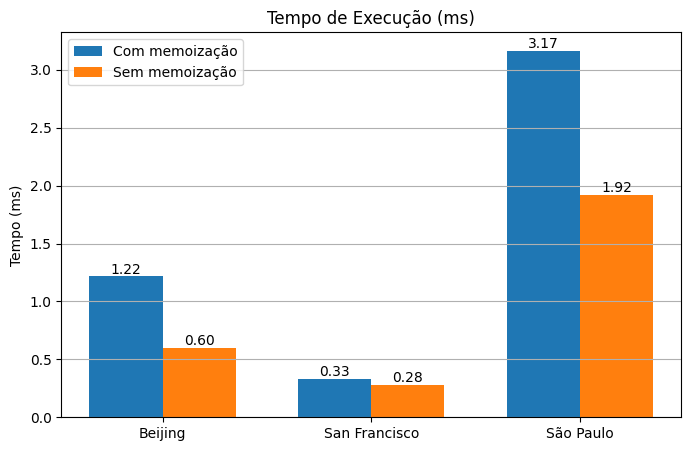

In [330]:
# GRÁFICO — TEMPO DE EXECUÇÃO

plt.figure(figsize=(8, 5))

cidades = [b["cidade"] for b in benchmarks]
x = range(len(cidades))
width = 0.35

bars1 = plt.bar([i - width/2 for i in x],
                [b["tempo_com_memo_ms"] for b in benchmarks],
                width,
                label="Com memoização")

bars2 = plt.bar([i + width/2 for i in x],
                [b["tempo_sem_memo_ms"] for b in benchmarks],
                width,
                label="Sem memoização")

plt.title("Tempo de Execução (ms)")
plt.ylabel("Tempo (ms)")
plt.xticks(list(x), cidades)
plt.legend()
plt.grid(axis='y')

# valores nas barras
for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}",
             ha='center', va='bottom')

plt.show()

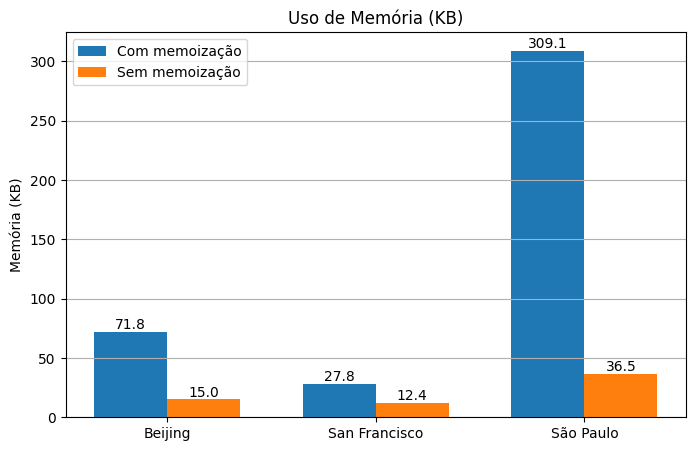

In [331]:
# GRÁFICO — USO DE MEMÓRIA

plt.figure(figsize=(8, 5))

bars3 = plt.bar([i - width/2 for i in x],
                [b["mem_com_memo_kb"] for b in benchmarks],
                width,
                label="Com memoização")

bars4 = plt.bar([i + width/2 for i in x],
                [b["mem_sem_memo_kb"] for b in benchmarks],
                width,
                label="Sem memoização")

plt.title("Uso de Memória (KB)")
plt.ylabel("Memória (KB)")
plt.xticks(list(x), cidades)
plt.legend()
plt.grid(axis='y')

for bar in list(bars3) + list(bars4):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.1f}",
             ha='center', va='bottom')

plt.show()

---

## [8] Visualização com Mapas (Folium)

Para cada cidade, geramos um mapa interativo com:
- Marcadores para cada estação (popup com nome)
- Linhas cinzas conectando estações adjacentes
- Caminho mais curto destacado em **verde**
- Caminho mais longo destacado em **vermelho**


In [332]:
# MAPA FINAL
def criar_mapa_metro(grafo, coords, caminho_curto, caminho_longo,
                     nome_cidade, centro, zoom=11):

    mapa = folium.Map(location=centro, zoom_start=zoom,
                      tiles="CartoDB positron")

    # TÍTULO

    titulo_html = f"""
    <div style="
        position: fixed;
        top: 10px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 1000;
        background: white;
        padding: 8px 16px;
        border-radius: 8px;
        box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
        font-size: 15px;
        font-weight: bold;">
        {nome_cidade}
    </div>
    """
    mapa.get_root().html.add_child(folium.Element(titulo_html))

    # GRAFO BASE (mais leve)

    desenhadas = set()

    for estacao, vizinhos in grafo.items():
        if estacao not in coords:
            continue

        for vizinho, peso in vizinhos:
            if vizinho not in coords:
                continue

            aresta = tuple(sorted([estacao, vizinho]))
            if aresta in desenhadas:
                continue

            desenhadas.add(aresta)

            folium.PolyLine(
                [coords[estacao], coords[vizinho]],
                weight=1,
                opacity=0.3
            ).add_to(mapa)

    # CAMINHO MAIS LONGO (VERMELHO)

    if caminho_longo and len(caminho_longo) > 1:
        pontos = [coords[e] for e in caminho_longo if e in coords]

        folium.PolyLine(
            pontos,
            color="red",
            weight=8,
            opacity=1,
            tooltip="Caminho mais longo"
        ).add_to(mapa)


    # CAMINHO MAIS CURTO (VERDE)

    if caminho_curto and len(caminho_curto) > 1:
        pontos = [coords[e] for e in caminho_curto if e in coords]

        folium.PolyLine(
            pontos,
            color="green",
            weight=7,
            opacity=1,
            tooltip="Caminho mais curto"
        ).add_to(mapa)

    # MARCAR INÍCIO E FIM

    if caminho_curto:
        folium.Marker(
            coords[caminho_curto[0]],
            popup="Origem",
            icon=folium.Icon(color="black", icon="play")
        ).add_to(mapa)

        folium.Marker(
            coords[caminho_curto[-1]],
            popup="Destino",
            icon=folium.Icon(color="black", icon="flag")
        ).add_to(mapa)

    # ESTAÇÕES

    set_curto = set(caminho_curto or [])
    set_longo = set(caminho_longo or [])

    for estacao, (lat, lon) in coords.items():

        if estacao in set_curto and estacao in set_longo:
            cor = "purple"
        elif estacao in set_curto:
            cor = "green"
        elif estacao in set_longo:
            cor = "red"
        else:
            cor = "blue"

        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            color=cor,
            fill=True,
            fill_opacity=0.9,
            popup=estacao
        ).add_to(mapa)

    return mapa

In [333]:
# MAPA — BEIJING

centro_beijing = (39.93, 116.40)

mapa_beijing = criar_mapa_metro(
    grafo=grafo_beijing,
    coords=coords_beijing,
    caminho_curto=caminho_curto_bj,
    caminho_longo=caminho_longo_bj,
    nome_cidade="Beijing — Metrô",
    centro=centro_beijing,
    zoom=12
)

# salvar arquivo
arquivo = "mapa_beijing.html"
mapa_beijing.save(arquivo)

print(f"Mapa salvo com sucesso: {arquivo}")

# exibir no notebook (Colab/Jupyter)
try:
    display(mapa_beijing)
except:
    print("Abra o arquivo HTML para visualizar o mapa.")

Mapa salvo com sucesso: mapa_beijing.html


In [334]:
# MAPA — SAN FRANCISCO (BART)

centro_sf = (37.78, -122.25)

mapa_sf = criar_mapa_metro(
    grafo=grafo_sf,
    coords=coords_sf,
    caminho_curto=caminho_curto_sf,
    caminho_longo=caminho_longo_sf,
    nome_cidade="San Francisco — BART",
    centro=centro_sf,
    zoom=11
)

# salvar arquivo
arquivo = "mapa_san_francisco.html"
mapa_sf.save(arquivo)

print(f"Mapa salvo com sucesso: {arquivo}")

# exibir no notebook
try:
    display(mapa_sf)
except:
    print("Abra o arquivo HTML para visualizar o mapa.")


print("\nLegenda rápida:")
print("Verde = caminho mais curto")
print("Vermelho = caminho mais longo")

Mapa salvo com sucesso: mapa_san_francisco.html



Legenda rápida:
Verde = caminho mais curto
Vermelho = caminho mais longo


In [335]:
# MAPA — SÃO PAULO


centro_sp = (-23.56, -46.67)

mapa_sp = criar_mapa_metro(
    grafo=grafo_sp,
    coords=coords_sp,
    caminho_curto=caminho_curto_sp,
    caminho_longo=caminho_longo_sp,
    nome_cidade="São Paulo — Metrô + CPTM",
    centro=centro_sp,
    zoom=12
)

# salvar arquivo
arquivo = "mapa_sao_paulo.html"
mapa_sp.save(arquivo)

print(f"Mapa salvo com sucesso: {arquivo}")

# exibir no notebook
try:
    display(mapa_sp)
except:
    print("Abra o arquivo HTML para visualizar o mapa.")


print("\nLegenda rápida:")
print("Verde = caminho mais curto")
print("Vermelho = caminho mais longo")
print("Caminho curto SP:", caminho_curto_sp)
print("Caminho longo SP:", caminho_longo_sp)
print(f"Custo curto: {custo_curto_sp} minutos")
print(f"Custo longo: {custo_longo_sp} minutos")

print("Qtd curto:", len(caminho_curto_sp) if caminho_curto_sp else 0)
print("Qtd longo:", len(caminho_longo_sp) if caminho_longo_sp else 0)

Mapa salvo com sucesso: mapa_sao_paulo.html



Legenda rápida:
Verde = caminho mais curto
Vermelho = caminho mais longo
Caminho curto SP: ['Tucuruvi', 'Parada Inglesa', 'Jardim São Paulo', 'Santana', 'Carandiru', 'Portuguesa-Tietê', 'Armênia', 'Tiradentes', 'Luz', 'República', 'Consolação', 'Trianon-Masp', 'Brigadeiro', 'Paraíso', 'Ana Rosa', 'Vila Mariana', 'Santa Cruz', 'Hospital São Paulo', 'AACD-Servidor', 'Moema', 'Eucaliptos', 'Campo Belo', 'Brooklin', 'Borba Gato', 'Alto da Boa Vista', 'Adolfo Pinheiro', 'Largo Treze', 'Santo Amaro', 'Giovanni Gronchi', 'Vila das Belezas', 'Campo Limpo', 'Capão Redondo']
Caminho longo SP: ['Tucuruvi', 'Parada Inglesa', 'Jardim São Paulo', 'Santana', 'Carandiru', 'Portuguesa-Tietê', 'Armênia', 'Tiradentes', 'Luz', 'São Bento', 'Sé', 'Anhangabaú', 'República', 'Consolação', 'Trianon-Masp', 'Brigadeiro', 'Paraíso', 'Ana Rosa', 'Chácara Klabin', 'Santa Cruz', 'Hospital São Paulo', 'AACD-Servidor', 'Moema', 'Eucaliptos', 'Campo Belo', 'Brooklin', 'Borba Gato', 'Alto da Boa Vista', 'Adolfo Pinhei

---

## [9] Conclusões

### Comparação entre Cidades


In [336]:
from IPython.display import display, Markdown

# Cria a tabela em Markdown injetando as variáveis calculadas pelo Python
tabela_dinamica = f"""
| Cidade | Estações (total do grafo) | Custo Curto (min) | Estações (curto) | Custo Longo (min) | Estações (longo) |
|---|---|---|---|---|---|
| **Beijing** | {len(grafo_beijing)} | {custo_curto_bj:.1f} | {len(caminho_curto_bj)} | {custo_longo_bj:.1f} | {len(caminho_longo_bj)} |
| **San Francisco** | {len(grafo_sf)} | {custo_curto_sf:.1f} | {len(caminho_curto_sf)} | {custo_longo_sf:.1f} | {len(caminho_longo_sf)} |
| **São Paulo** | {len(grafo_sp)} | {custo_curto_sp:.1f} | {len(caminho_curto_sp)} | {custo_longo_sp:.1f} | {len(caminho_longo_sp)} |
"""

# Exibe a tabela renderizada lindamente no notebook
display(Markdown(tabela_dinamica))


| Cidade | Estações (total do grafo) | Custo Curto (min) | Estações (curto) | Custo Longo (min) | Estações (longo) |
|---|---|---|---|---|---|
| **Beijing** | 32 | 26.4 | 13 | 31.2 | 16 |
| **San Francisco** | 38 | 42.6 | 18 | 45.6 | 19 |
| **São Paulo** | 48 | 58.8 | 32 | 64.8 | 35 |


*(Os valores são preenchidos automaticamente ao executar as células acima.)*

---

### Benefícios da Memoização

A memoização com `lru_cache` ajuda bastante a melhorar o desempenho do algoritmo de caminho mais curto.

1. **Evita cálculos repetidos:**
   Durante a execução, o algoritmo acaba passando várias vezes pelos mesmos estados. Com o cache, esses resultados já ficam guardados, então não precisam ser recalculados.

2. **Melhora no tempo de execução:**
   Na prática, dá pra perceber que o algoritmo com memoização roda bem mais rápido, principalmente quando o grafo tem várias rotas possíveis.

3. **Uso de memória:**
   Como os resultados ficam armazenados, o consumo de memória aumenta um pouco. Mesmo assim, vale a pena, porque o ganho em velocidade compensa.

---

### Diferença entre Caminho Mais Curto e Mais Longo

| Aspecto      | Mais Curto                    | Mais Longo                             |
| ------------ | ----------------------------- | -------------------------------------- |
| Algoritmo    | Recursão + memoização         | Backtracking                           |
| Objetivo     | Minimizar o custo total       | Maximizar o custo sem repetir estações |
| Memoização   | Funciona bem                  | Não ajuda muito                        |
| Complexidade | Alta, mas otimizada com cache | Muito alta                             |
| Uso prático  | Encontrar rotas eficientes    | Explorar mais caminhos                 |

---

### Impacto dos Fatores de Horário

| Horário | Fator | Efeito                               |
| ------- | ----- | ------------------------------------ |
| 05h–07h | ×0.6  | Viagem mais rápida (menos movimento) |
| 07h–09h | ×1.5  | Aumenta o tempo (pico da manhã)      |
| 09h–17h | ×1.0  | Normal                               |
| 17h–20h | ×2.0  | Tempo bem maior (pico da tarde)      |

Dá pra ver que o horário influencia bastante no resultado. Em horários de pico, principalmente à tarde, os caminhos ficam mais “caros”, então o algoritmo de caminho mais curto fica ainda mais importante.

---

### Conclusão Final

No geral, o uso de grafos para representar o metrô funciona muito bem e facilita bastante a aplicação dos algoritmos.

A memoização ajuda a deixar o caminho mais curto bem mais rápido de calcular, enquanto o caminho mais longo serve mais para análise do grafo do que para uso prático.

Além disso, considerar o horário deixa o modelo mais próximo da realidade, já que o tempo de deslocamento realmente varia ao longo do dia.
